# Figure 5: LMFG and RMTG are linked through PBC

In [1]:
# Adjust the path to the root data folder containing dataset_description.json, sourcedata/, etc.
DATA_PATH = "/Volumes/External/dataset/"
SUBJECTS = [f"sub-P{k}" for k in range(1, 8)]

In [13]:
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import uniform_filter1d
from scipy.stats import permutation_test, ttest_rel
from astropy.stats import rayleightest

# Adjust the path to the location of burst_toolbox
import sys
sys.path.append("/Users/vladimiromelyusik/burst_toolbox/src")

from burst_toolbox.dsp import compute_power
from burst_toolbox.stats import cluster_test_period, cluster_correct
from burst_toolbox.bursts import detect_bursts
from burst_toolbox.coupling import phase_lag_index, compute_phase_burst_counts, phase_burst_coupling

## Data processing

In [3]:
# Read the data
data = utils.read_openneuro(path = DATA_PATH, subjects = SUBJECTS)
data["sc"] = data["subject"] + "_" + data["channel"].astype(str)

data.head()

Extracting EDF parameters from /Volumes/External/dataset/sub-P1/ieeg/sub-P1_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P2/ieeg/sub-P2_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P3/ieeg/sub-P3_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P4/ieeg/sub-P4_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P5/ieeg/sub-P5_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P6/ieeg/sub-P6_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters fr

,LFP_0,LFP_1,LFP_2,LFP_3,LFP_4,LFP_5,LFP_6,LFP_7,LFP_8,LFP_9,...,LFP_6495,LFP_6496,LFP_6497,subject,region,channel,modulated,trial_idx,n_correct,sc
0,32.028687,34.012360,35.965515,38.284886,42.282750,46.219577,48.905165,48.416876,47.501335,48.447395,...,28.000305,22.201877,19.211109,sub-P1,LMTG,23,1,1,0,sub-P1_23
1,-3.463798,-2.029450,-3.189136,-2.944991,-1.266499,-1.510643,-2.975509,-5.050736,-7.461662,-8.285649,...,15.274281,16.739147,17.746242,sub-P1,LMTG,23,1,3,0,sub-P1_23
2,-107.316701,-102.952621,-97.398337,-92.912184,-89.311055,-83.176928,-77.317464,-74.113069,-72.892348,-71.580072,...,-29.953460,-26.565957,-22.079805,sub-P1,LMTG,23,1,5,2,sub-P1_23
3,18.722820,19.394217,21.347372,24.551766,24.887465,23.544671,21.774624,19.607843,16.433967,13.076982,...,-25.528344,-26.199741,-27.908751,sub-P1,LMTG,23,1,8,3,sub-P1_23
4,-20.767529,-22.873274,-25.223163,-26.169223,-23.300526,-18.326085,-16.159304,-14.450294,-9.201190,-1.144427,...,-50.827802,-52.079042,-53.177691,sub-P1,LMTG,23,1,10,3,sub-P1_23


In [4]:
# Compute power and detect high gamma and beta bursts
processed_data = []

for region in ["LMFG", "RMTG"]:
    for freq_band in ["beta", "high_gamma"]:
        for subject_channel in data[data["region"] == region]["sc"].unique():
            subject, channel = subject_channel.split("_")
            channel = int(channel)
            
            # Compute power
            channel_data = data[(data["subject"] == subject) & (data["channel"] == channel)]
            power = compute_power(LFP = channel_data[utils.LFP_COLS].to_numpy(), freq_band = utils.FREQ_BANDS[freq_band])

            # Detect bursts
            bursts = detect_bursts(
                power = power,
                reference_period = np.array([1, 1000]),
                min_dur_ms = 3 * 1000 / np.mean(utils.FREQ_BANDS[freq_band])
            )

            composite = pd.DataFrame(np.hstack((power, bursts)), columns = utils.POWER_COLS + utils.BURST_COLS)
            composite["subject"] = subject
            composite["region"] = region
            composite["channel"] = channel
            composite["freq_band"] = freq_band
            composite["trial_idx"] = channel_data["trial_idx"].to_numpy()
            composite["modulated"] = channel_data["modulated"].to_numpy()
            composite["n_correct"] = channel_data["n_correct"].to_numpy()

            processed_data.append(composite)

processed_data = pd.concat(processed_data, axis = 0, ignore_index = True)
processed_data.head()

,power_0,power_1,power_2,power_3,power_4,power_5,power_6,power_7,power_8,power_9,...,bursts_6495,bursts_6496,bursts_6497,subject,region,channel,freq_band,trial_idx,modulated,n_correct
0,6.544030,6.646046,7.782911,8.412919,9.411584,10.192759,11.193510,12.118448,13.185223,14.266943,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,1,0,0
1,22.869988,21.754875,25.859255,27.594122,31.066299,33.319479,36.367352,38.748520,41.384938,43.700259,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,5,0,2
2,18.133333,13.194748,14.400935,14.721481,15.737993,16.884758,17.844060,19.368527,20.313834,22.074690,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,8,0,3
3,9.327621,9.027730,10.030496,10.360521,11.160145,11.586686,12.289968,12.757604,13.408420,13.907587,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,10,0,3
4,12.486770,11.636928,13.984695,15.061250,17.071779,18.609779,20.457306,22.228373,23.953539,25.845476,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,12,0,3


## Beta-beta dPLI (Fig. 5a)

In [5]:
dpli_estimates = {
    "correct": [],
    "incorrect": []
}

for subject in ["sub-P1", "sub-P6"]:
    for channel_from in data[(data["subject"] == subject) & (data["region"] == "LMFG") & (data["modulated"] == 1)]["channel"].unique():
        for channel_to in data[(data["subject"] == subject) & (data["region"] == "RMTG") & (data["modulated"] == 1)]["channel"].unique():

            for perf in ["correct", "incorrect"]:

                if perf == "correct":
                    perf_cond = data["n_correct"] == 3
                else:
                    perf_cond = data["n_correct"] <= 1

                # Match trials
                channel1_trials = set(data[(data["subject"] == subject) & (data["channel"] == channel_from) & perf_cond]["trial_idx"])
                channel2_trials = set(data[(data["subject"] == subject) & (data["channel"] == channel_to) & perf_cond]["trial_idx"])
                common_trials = channel1_trials.intersection(channel2_trials)

                channel1_LFP = data[
                    (data["subject"] == subject) & 
                    (data["channel"] == channel_from) & 
                    (data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[utils.LFP_COLS].to_numpy()
            
                channel2_LFP = data[
                    (data["subject"] == subject) & 
                    (data["channel"] == channel_to) & 
                    (data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[utils.LFP_COLS].to_numpy()
                
                assert(channel1_LFP.shape == channel2_LFP.shape)

                # Compute dPLI
                channel_matrix = np.stack([channel1_LFP, channel2_LFP])
                f, t, dpli = phase_lag_index(
                    LFP = channel_matrix,
                    directed = True
                )
                # Normalize to 0
                dpli_estimates[perf].append(dpli - 0.5)

for perf in ["correct", "incorrect"]:
    dpli_estimates[perf] = np.stack(dpli_estimates[perf])

In [7]:
# Vector form for efficiency
def statistic_mean(x, y, axis):
    return ttest_rel(x, y, axis).statistic

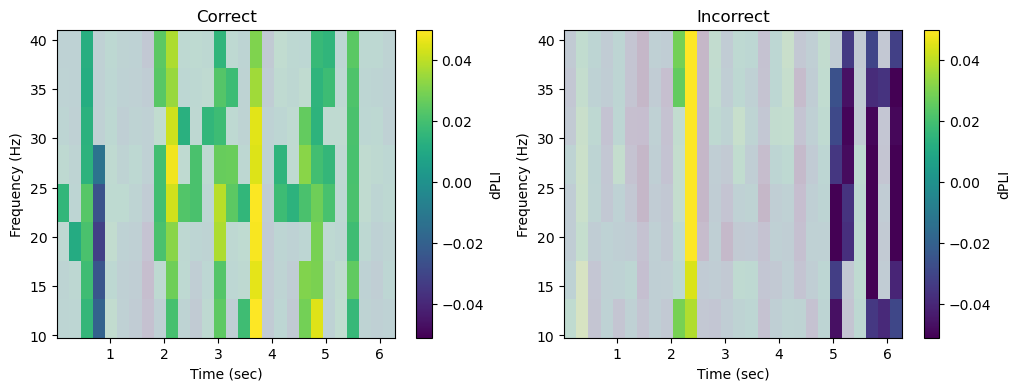

In [8]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))

f_cond = (f > 10) & (f < 40)

for col_id, perf in enumerate(["correct", "incorrect"]):
    ca = ax[col_id]

    dpli = dpli_estimates[perf]
    dpli = dpli[:, f_cond, :]
    dpli = dpli - np.nanmean(dpli[:, :, 1 : 4], axis = 2, keepdims = True)

    im = ca.pcolormesh(t, f[f_cond], np.nanmean(dpli, axis = 0), cmap = "viridis", vmin = -0.051, vmax = 0.05)

    ca.set_xlabel("Time (sec)")
    ca.set_ylabel("Frequency (Hz)")
    ca.set_title(utils.PLOTTING[perf]["title"])

    sample_test = dpli
    sample_fix = np.nanmean(sample_test[:, :, 1 : 4], axis = 2, keepdims = True)

    # Cluster-test
    test = permutation_test(
        data = (sample_test, sample_fix),
        statistic = statistic_mean,
        permutation_type = "samples",
        n_resamples = 1000,
        random_state = np.random.RandomState(123),
        vectorized = True
    )

    try:
        cluster_result = cluster_correct(test.null_distribution, test.statistic)
    except:
        cluster_result = []

    # Show clusters
    cluster_cmap = ListedColormap([
        (0.9, 0.9, 0.9, 0.8),
        (0, 0, 0, 0.0)
        ])
    if len(cluster_result) > 0:
        ca.pcolormesh(t, f[f_cond], cluster_result, cmap = cluster_cmap)

    fig.colorbar(im, label = f"dPLI")

## Beta (LMFG) – High gamma (RMTG) PBC without baseline subtraction (Fig. 5b)

**Note:** takes ~4 min. to run.

In [10]:
pbc_estimates = {
    "LMFG2RMTG": {
        "pbc": [],
        "counts": []
    },
    "RMTG2LMFG": {
        "pbc": [],
        "counts": []
    }
}

for region_from, region_to in [("LMFG", "RMTG"), ("RMTG", "LMFG")]:
    for subject in ["sub-P1", "sub-P6"]:
        for channel_from in data[(data["subject"] == subject) & (data["region"] == region_from) & (data["modulated"] == 1)]["channel"].unique():
            for channel_to in processed_data[(processed_data["subject"] == subject) & (processed_data["region"] == region_to) & (processed_data["modulated"] == 1)]["channel"].unique():

                # Match trials
                channel1_trials = set(data[(data["subject"] == subject) & (data["channel"] == channel_from) & (data["n_correct"] == 3)]["trial_idx"])
                channel2_trials = set(processed_data[(processed_data["subject"] == subject) & (processed_data["channel"] == channel_to) & (processed_data["n_correct"] == 3)]["trial_idx"])
                common_trials = channel1_trials.intersection(channel2_trials)

                channel1_LFP = data[
                    (data["subject"] == subject) & 
                    (data["channel"] == channel_from) & 
                    (data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[utils.LFP_COLS].to_numpy()
            
                channel2_bursts = processed_data[
                    (processed_data["subject"] == subject) & 
                    (processed_data["channel"] == channel_to) &
                    (processed_data["freq_band"] == "high_gamma") & 
                    (processed_data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[utils.BURST_COLS].to_numpy()
                
                assert(channel1_LFP.shape == channel2_bursts.shape)

                # Compute PBC
                phase_burst_counts = compute_phase_burst_counts(
                    LFP = channel1_LFP,
                    bursts = channel2_bursts,
                    filter = True,
                    phase_freq_band = np.array([12, 30])
                ) # (num_trials, time, num_bins)

                pbc = phase_burst_coupling(phase_burst_counts)
                pbc_estimates[f"{region_from}2{region_to}"]["pbc"].append(pbc)

                # Remove 0-burst trials
                phase_burst_counts = phase_burst_counts[~(phase_burst_counts.sum(axis = (1, 2)) == 0)]
                pbc_estimates[f"{region_from}2{region_to}"]["counts"].append(np.nansum(phase_burst_counts, axis = 0))

for region_from, region_to in [("LMFG", "RMTG"), ("RMTG", "LMFG")]:
    for data_type in ["pbc", "counts"]:
        pbc_estimates[f"{region_from}2{region_to}"][data_type] = np.stack(pbc_estimates[f"{region_from}2{region_to}"][data_type])

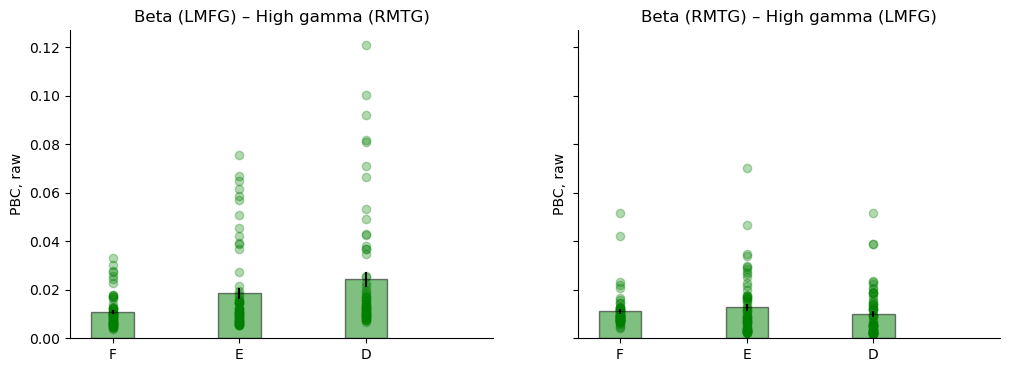

In [11]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4), sharey = True)

for col_id, region_pair in enumerate(["LMFG2RMTG", "RMTG2LMFG"]):
        
    ca = ax[col_id]

    pbc = pbc_estimates[region_pair]["pbc"]
    n_channels = len(pbc)

    # Compute stats
    offset = 0
    for period_bounds, period_label in zip([(100, 1000), (1000, 2500), (2500, 6000)], ["F", "E", "D"]):
        period_avg_pbc = np.nanmean(pbc[:, period_bounds[0] : period_bounds[1]], axis = 1)
        avg_pbc = np.nanmean(period_avg_pbc)
        sem_pbc = np.nanstd(period_avg_pbc) / np.sqrt(n_channels)

        ca.scatter(
            [offset] * len(period_avg_pbc),
            period_avg_pbc,
            color = utils.PLOTTING["correct"]["color"],
            alpha = 0.3
        )

        ca.bar(
            offset, 
            avg_pbc,
            width = 0.1,
            color = utils.PLOTTING["correct"]["color"],
            alpha = 0.5, 
            edgecolor = 'black', 
            yerr = sem_pbc, 
            ecolor = "black"
        )
        offset += 0.3

    ca.set_xticks([0.0, 0.3, 0.6], labels = ["F", "E", "D"])
    
    title = f"Beta ({region_pair.split('2')[0]}) – High gamma ({region_pair.split('2')[1]})"
    ca.set_title(title)

    ca.set_ylabel("PBC, raw")
    ca.set_xlim(-0.1, 0.9)
    ca.spines[["top", "right"]].set_visible(False)

fig.align_labels()
plt.subplots_adjust(wspace = 0.2)

## Baseline-subtracted PBC (Fig. 5c)

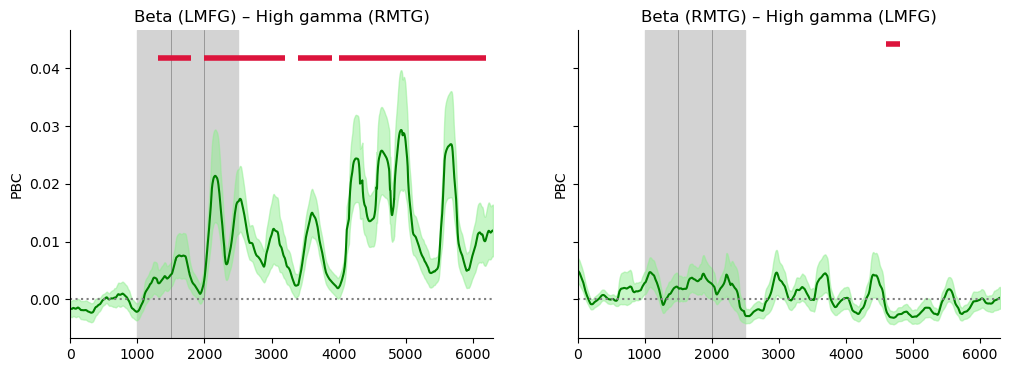

In [12]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4), sharey = True)

for col_id, region_pair in enumerate(["LMFG2RMTG", "RMTG2LMFG"]):
        
    ca = ax[col_id]
    ca.axvspan(1000, 2500, color = 'lightgray')
    ca.axvline(1500, color = 'gray', linewidth = 0.5)
    ca.axvline(2000, color = 'gray', linewidth = 0.5)

    pbc = pbc_estimates[region_pair]["pbc"]

    # Baseline-correct
    pbc = pbc - np.nanmean(pbc[:, utils.BASELINE[0] : utils.BASELINE[1]], axis = 1, keepdims = True)
    pbc = pbc[:, :utils.CUTOFF]
    n_channels = len(pbc)

    # Compute stats
    avg_pbc = np.nanmean(pbc, axis = 0)
    sem_pbc = np.nanstd(pbc, axis = 0) / np.sqrt(n_channels)

    # Plot PBC
    ca.plot(
        np.arange(utils.CUTOFF),
        uniform_filter1d(avg_pbc, 200),
        color = utils.PLOTTING["correct"]["color"]
    )
    ca.fill_between(
        np.arange(utils.CUTOFF),
        uniform_filter1d(avg_pbc - sem_pbc, 200),
        uniform_filter1d(avg_pbc + sem_pbc, 200),
        color = utils.PLOTTING["correct"]["fillcolor"],
        alpha = 0.5
    )

    # Cluster-test
    step = 100
    win_range = np.arange(0, utils.CUTOFF, step)  # Was (100, 6400) when working on the paper, now using (0, 6300)
    clusters = cluster_test_period(
        sample = pbc,
        period = utils.BASELINE,
        win_range = win_range,
        win_size = 200,
        stat_q_threshold = 0.975
    )

    if len(clusters) > 0:
        yval = ca.get_ylim()[1]
        for tstat_id, period in enumerate(win_range):
            if (period < 100) or (period >= utils.CUTOFF - 100): continue
            if clusters[tstat_id] == 0: continue
            ca.hlines(yval, period, period + step, color = 'crimson', linewidth = 4)
    
    title = f"Beta ({region_pair.split('2')[0]}) – High gamma ({region_pair.split('2')[1]})"
    ca.set_title(title)

    ca.set_ylabel("PBC")
    ca.set_xlim(0, utils.CUTOFF)
    ca.spines[["top", "right"]].set_visible(False)
    ca.axhline(0, ls = "dotted", color = "gray")

fig.align_labels()
plt.subplots_adjust(wspace = 0.2)

## Distribution of delay-period high gamma bursts in RMTG over the beta phase of LMFG (Fig. 5d)

In [14]:
def rayleigh_test(counts, edge_labels, pval_correction):
    ### counts: (channels x phase bins)
    
    significant_channel_idxs = []

    for channel_idx in range(len(counts)):
        # Construct count distribution
        distribution = []
        for lab_idx, lab in enumerate(edge_labels):
            distribution.extend([lab] * int(counts[channel_idx, lab_idx]))

        distribution = np.array(distribution)
        pval = rayleightest(np.deg2rad(distribution))
        
        if pval < (0.05 / pval_correction): # Bonferroni correction
            significant_channel_idxs.append(channel_idx)
            
    return significant_channel_idxs

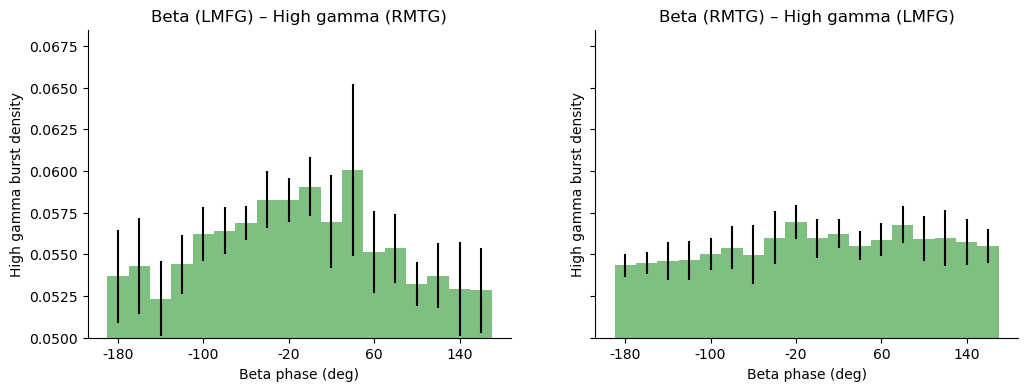

In [15]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4), sharey = True)

for col_id, region_pair in enumerate(["LMFG2RMTG", "RMTG2LMFG"]):
        
    ca = ax[col_id]

    # Get delay-period counts
    pbd = pbc_estimates[region_pair]["counts"][:, 3000 : 5500, :]
    pbd = np.nansum(pbd, axis = 1)

    # Leave only channel pairs different from the uniform distribution
    edge_labels = np.array([-180 + d * 20 for d in range(18)])
    signif = rayleigh_test(pbd, edge_labels, len(pbd) * 4500)
    phase = pbd[signif]
    
    
    # Normalize through time
    phase = phase / 2500

    # Normalize to a distribution
    C = np.nansum(phase, axis = -1, keepdims = True)
    phase = phase / C
    
    mean_phase = np.nanmean(phase, axis = 0)
    sem_phase = np.nanstd(phase, axis = 0) / np.sqrt(len(phase))

    ca.bar(range(0, 5 * 18, 5), mean_phase, width = 5, color = utils.PLOTTING["correct"]["color"], alpha = 0.5, yerr = sem_phase)

    ca.set_xticks(range(0, 5 * 18, 5)[::4])
    ca.set_xticklabels(edge_labels[::4])
    
    title = f"Beta ({region_pair.split('2')[0]}) – High gamma ({region_pair.split('2')[1]})"
    ca.set_title(title)

    ca.set_xlabel("Beta phase (deg)")
    ca.set_ylabel("High gamma burst density")
    ca.spines[["top", "right"]].set_visible(False)

    ca.set_ylim(0.05)

fig.align_labels()
plt.subplots_adjust(wspace = 0.2)